In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [212]:
df_1 = pd.read_csv("Dhaka Rent.csv", sep=';')
df_1.head()

,area,rent
0,2000,31500
1,2100,35000
2,2500,41050
3,2250,36100
4,3000,52100


In [213]:
df_2 = pd.read_csv('Student_Performance.csv')
df_2.drop("Extracurricular Activities", axis=1, inplace=True)
df_2.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [214]:
df_3 = pd.read_csv('manufacturing.csv')
df_3.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [215]:
df_4 = pd.read_csv("Ice_cream selling data.csv")
df_4.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


# Classes

In [216]:
#Simple Linear Reg.
class SimpleLinearReg():
    def __init__(self):
        self.coef = None
        self.intercept = None


    def fit(self, x, y):
        dev_x = x.iloc[:,0] - x.iloc[:,0].mean()
        dev_y = y - y.mean()
        m = (dev_x * dev_y).sum()/ (dev_x**2).sum()
        c = y.mean() - x.iloc[:,0].mean() * m

        self.coef = m
        self.intercept = c


    def predict(self, x):
        return (self.coef*(x.iloc[:,0]) + self.intercept)

In [217]:
#General Linear Re. Should work for simple linear, multiple linear and plynomial Reg.
class GeneralLinearReg():
    def __init__(self):
        self.coef = None
        self.intercept = None
        self.bita = None
        self.digree = None


    def polynomialFeatures(self, x, degree):
        x_dev = x.copy()
        for col in x_dev:
            for deg in range(2, degree+1):
                new_col = x_dev[col]**deg
                x_dev[f"{col}^{deg}"] = new_col
        return x_dev
    
            
    def fit(self, x, y, degree=1):
        x_dev = self.polynomialFeatures(x=x, degree=degree)
        x_dev.insert(0, 'intercept', 1)
        x_dev = np.array(x_dev)
        y_dev = np.array(y.copy())

        # bita = (np.linalg.inv(x_dev.T @ x_dev)) @ (x_dev.T @ y_dev)
        bita = (np.linalg.pinv(x_dev.T @ x_dev)) @ (x_dev.T @ y_dev)
        # bita = np.linalg.lstsq(x_dev, y_dev, rcond=None)[0]

        self.coef = bita[1:]
        self.intercept = bita[0]
        self.bita = bita
        self.digree = degree


    def predict(self, x):
        dev_x = self.polynomialFeatures(x=x, degree=self.digree)
        dev_x.insert(0, 'intercept', 1)
        dev_x = np.array(dev_x)
        pred_y = dev_x @ self.bita
        
        return pred_y

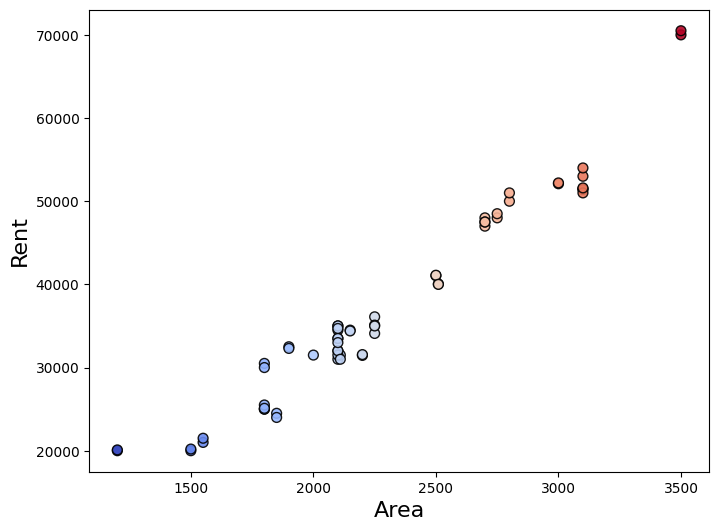

In [218]:
plt.figure(figsize=(8,6))
plt.scatter(df_1.iloc[:,0], 
            df_1.iloc[:,1],
            c=df_1.iloc[:,0],
            cmap="coolwarm",
            s=50,
            edgecolor="k",
            alpha=0.9
            )
plt.xlabel("Area", fontsize=16)
plt.ylabel("Rent", fontsize=16)
plt.show()

In [219]:
# Splitting df_1
x = df_1.iloc[:,[0]]
y=df_1.iloc[:,1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Simple Linear Regression

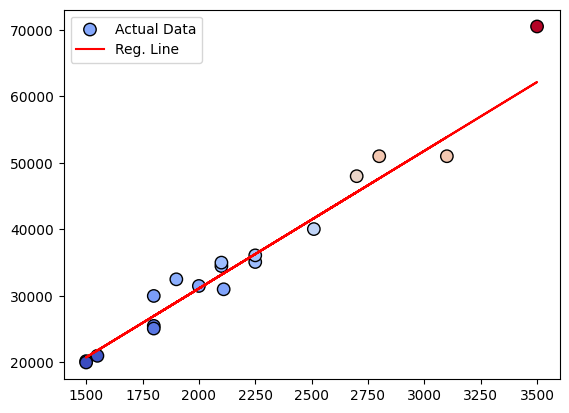

In [220]:
sk_model_1 = LinearRegression()
sk_model_1.fit(x_train, y_train)

sk_model_1_pred = sk_model_1.predict(x_test)
sk_model_1_r2 = r2_score(y_test, sk_model_1_pred)

plt.scatter(x_test,
            y_test,
            label="Actual Data",
            c=y_test,
            cmap='coolwarm',
            edgecolors='k',
            s=80
            )
plt.plot(x_test, sk_model_1_pred, color='red', label="Reg. Line")
plt.legend()
plt.show()

In [221]:
my_model_1 = SimpleLinearReg()
my_model_1.fit(x_train, y_train)

my_model_1_pred = my_model_1.predict(x_test)
my_model_1_r2 = r2_score(y_test, my_model_1_pred)

In [222]:
my_model_1_1 = GeneralLinearReg()
my_model_1_1.fit(x_train, y_train)

my_model_1_1_pred = my_model_1.predict(x_test)
my_model_1_1_r2 = r2_score(y_test, my_model_1_pred)

In [223]:
print(sk_model_1.coef_, my_model_1.coef, my_model_1_1.coef)
print(sk_model_1.intercept_, my_model_1.intercept, my_model_1_1.intercept)
print(sk_model_1_r2, my_model_1_r2, my_model_1_1_r2)

[20.68636687] 20.6863668715626 [20.68636687]
-10252.90474033673 -10252.904740336766 -10252.904740016513
0.9515542918540623 0.9515542918540623 0.9515542918540623


In [224]:
# Splitting df_2
x = df_2.iloc[:,:-1]
y = df_2.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Multiple Linear Regression

In [225]:
sk_model_2 = LinearRegression()
sk_model_2.fit(x_train, y_train)

sk_model_2_pred = sk_model_2.predict(x_test)
sk_model_2_r2 = r2_score(y_test, sk_model_2_pred)

In [226]:
my_model_2 = GeneralLinearReg()
my_model_2.fit(x_train, y_train)

my_model_2_pred = my_model_2.predict(x_test)
my_model_2_r2 = r2_score(y_test, sk_model_2_pred)

In [227]:
print(sk_model_2.coef_, my_model_2.coef)
print(sk_model_2.intercept_, my_model_2.intercept)
print(sk_model_2_r2, my_model_2_r2)

[2.85289351 1.01703572 0.47331832 0.19172629] [2.85289351 1.01703572 0.47331832 0.19172629]
-33.60206732749263 -33.60206732744753
0.9887144552384186 0.9887144552384186


In [228]:
# Splitting df_3
x = df_3.iloc[:,:-1]
y = df_3.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Polynomial Regression

In [229]:
sk_model_3 = make_pipeline(PolynomialFeatures(degree=14), LinearRegression())
sk_model_3.fit(x_train, y_train)

sk_model_3_pred = sk_model_3.predict(x_test)
sk_model_3_r2 = r2_score(y_test, sk_model_3_pred)
sk_model_3_r2

1.0

In [230]:
my_model_3 = GeneralLinearReg()
my_model_3.fit(x_train, y_train, degree=14)

my_model_3_pred = my_model_3.predict(x_test)
my_model_3_r2 = r2_score(y_test, my_model_3_pred)

#I don't know why it works so horribly when applied to polynomial data with multiple features
my_model_3_r2

-44.32658178412076

##### Seems Like the code works for Simple Linear and Multiple Linear reg. but works horribly for polynomial regression with multiple features

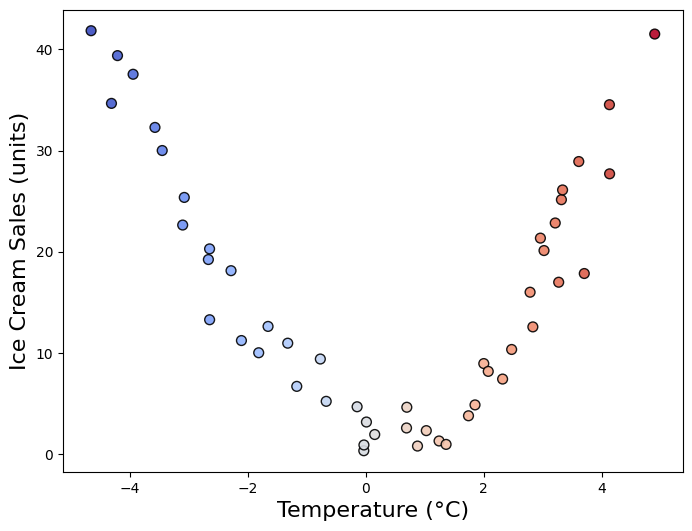

In [231]:
# Lets test my code with a polynomial data with 1 feature

plt.figure(figsize=(8,6))
plt.scatter(df_4.iloc[:,0], 
            df_4.iloc[:,1],
            c=df_4.iloc[:,0],
            cmap="coolwarm",
            s=50,
            edgecolor="k",
            alpha=0.9
            )
plt.xlabel("Temperature (°C)", fontsize=16)
plt.ylabel("Ice Cream Sales (units)", fontsize=16)
plt.show()

In [232]:
x = df_4.iloc[:,:-1]
y = df_4.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [260]:
sk_model_4 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
sk_model_4.fit(x_train, y_train)

sk_model_4_pred = sk_model_4.predict(x_test)
sk_model_4_r2 = r2_score(y_test, sk_model_4_pred)
sk_model_4_r2

0.843055137193884

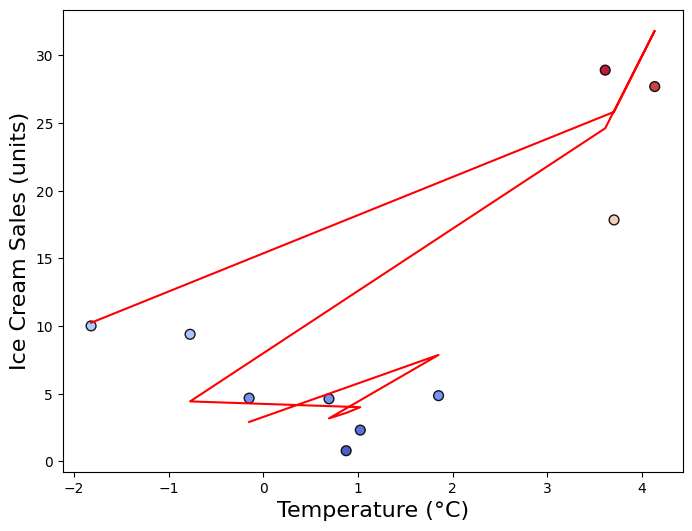

In [261]:
plt.figure(figsize=(8,6))
plt.scatter(x_test, 
            y_test,
            c=y_test,
            cmap="coolwarm",
            s=50,
            edgecolor="k",
            alpha=0.9
            )
plt.plot(x_test, sk_model_4_pred, color='red')
plt.xlabel("Temperature (°C)", fontsize=16)
plt.ylabel("Ice Cream Sales (units)", fontsize=16)
plt.show()

In [263]:
my_model_4 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
my_model_4.fit(x_train, y_train)

my_model_4_pred = my_model_4.predict(x_test)
my_model_4_r2 = r2_score(y_test, my_model_4_pred)

In [265]:
print(sk_model_4_r2, my_model_4_r2)

0.843055137193884 0.843055137193884


##### THE CLASS ALSO WORKS PERFECTLY FOR POLYNOMIAL REGRESSION WITH WITH ONE INDEPENDENT FEATURE
##### I WONDER WHY IT DOESN'T WORK WITH POLYNOMIAL WITH MULTIPLE FEATURES